In [12]:
import nltk
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import gutenberg

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\Hrisi\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hrisi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hrisi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
#Question 1
#Using Moby Dick from the Gutenberg corpus

words_raw = gutenberg.words('melville-moby_dick.txt')

#Defines a 'unique word' as lowercased, alphabetic tokens only
#Filtering out specific artifacts like s and t, which are just noise and not actual words
#Better than a blanket single-character filter because characters like 'a' or 'i' can be considered words
ARTIFACT_TOKENS = {'s', 't'}
words = [w.lower() for w in words_raw if w.isalpha() and w.lower() not in ARTIFACT_TOKENS]

print(f"Total tokens (filtered): {len(words):,}")
print(f"Sample: {words[:10]}")

Total tokens (filtered): 216,268
Sample: ['moby', 'dick', 'by', 'herman', 'melville', 'etymology', 'supplied', 'by', 'a', 'late']


In [15]:
#Question 2
#Unique Word Count

unique_words = set(words)
print(f"Total unique words: {len(unique_words):,}")
print("""
Definition: A 'unique word' is a distinct lowercase alphabetic token.
Punctuation, numbers, and mixed tokens are excluded. Case is folded so
'Whale' and 'whale' count as the same word.
""")

Total unique words: 16,946

Definition: A 'unique word' is a distinct lowercase alphabetic token.
Punctuation, numbers, and mixed tokens are excluded. Case is folded so
'Whale' and 'whale' count as the same word.



In [16]:
#Question 3
#Words Covering Half the Corpus

freq = Counter(words)
total_tokens = len(words)
half = total_tokens / 2

cumulative = 0
words_to_half = 0
for word, count in freq.most_common():
    cumulative += count
    words_to_half += 1
    if cumulative >= half:
        break

print(f"Total tokens: {total_tokens:,}")
print(f"Tokens needed to reach 50%: {cumulative:,}")
print(f"Unique words needed to cover half the corpus: {words_to_half}")
print(f"That's {words_to_half / len(unique_words) * 100:.2f}% of all unique words.")

Total tokens: 216,268
Tokens needed to reach 50%: 108,245
Unique words needed to cover half the corpus: 92
That's 0.54% of all unique words.


In [17]:
#Question 4
#Top 200 Words

top_200 = freq.most_common(200)
top_words, top_counts = zip(*top_200)

print("Top 20 words:")
for word, count in top_200[:20]:
    print(f"  {word:<15} {count:>6}")

Top 20 words:
  the              14431
  of                6609
  and               6430
  a                 4736
  to                4625
  in                4172
  that              3085
  his               2530
  it                2522
  i                 2127
  he                1896
  but               1818
  as                1741
  is                1725
  with              1722
  was               1644
  for               1617
  all               1526
  this              1394
  at                1319


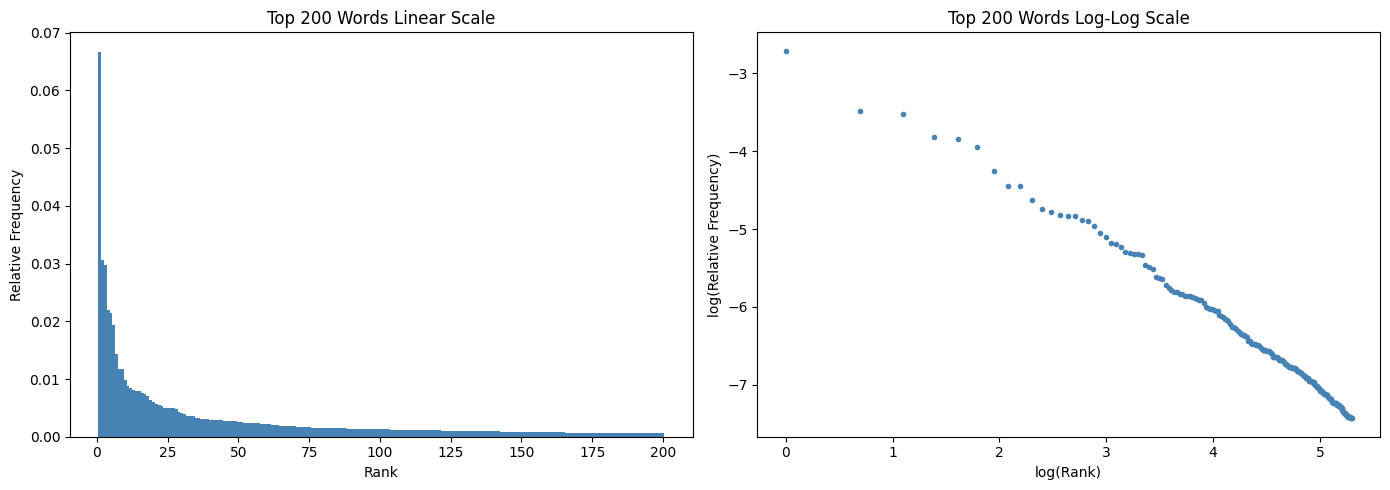

In [18]:
#Question 5
#Frequency graph of these top 200 words

ranks = np.arange(1, 201)
relative_freqs = [c / total_tokens for c in top_counts]

plt.figure(figsize=(14, 5))

#Linear scale
plt.subplot(1, 2, 1)
plt.bar(ranks, relative_freqs, color='steelblue', width=1.0)
plt.xlabel("Rank")
plt.ylabel("Relative Frequency")
plt.title("Top 200 Words Linear Scale")

#Log-log scale (better for Zipf inspection)
plt.subplot(1, 2, 2)
plt.plot(np.log(ranks), np.log(relative_freqs), 'o', markersize=3, color='steelblue')
plt.xlabel("log(Rank)")
plt.ylabel("log(Relative Frequency)")
plt.title("Top 200 Words Log-Log Scale")

plt.tight_layout()
plt.show()

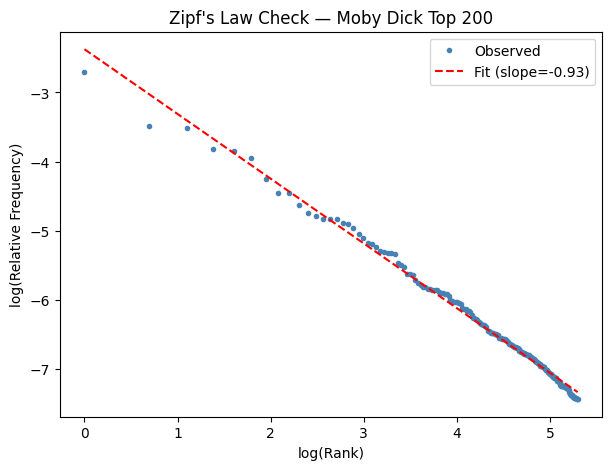

Fitted slope: -0.9348793670435238
Zipf's law predicts a slope of -1.0
Deviation from ideal: 0.06512063295647619


In [21]:
#Question 6
#Zipf's law analysis
#Zipf's law states that in a large corpus, the frequency of any word is inversely proportional to its rank

log_ranks = np.log(ranks)
log_freqs = np.log(relative_freqs)
slope, intercept = np.polyfit(log_ranks, log_freqs, 1)

plt.figure(figsize=(7, 5))
plt.plot(log_ranks, log_freqs, 'o', markersize=3, label='Observed', color='steelblue')
plt.plot(log_ranks, slope * log_ranks + intercept, '--', color='red',
         label=f'Fit (slope={slope:.2f})')
plt.xlabel("log(Rank)")
plt.ylabel("log(Relative Frequency)")
plt.title("Zipf's Law Check — Moby Dick Top 200")
plt.legend()
plt.show()

print(f"Fitted slope: {slope}")
print(f"Zipf's law predicts a slope of -1.0")
print(f"Deviation from ideal: {abs(slope - (-1.0))}")

Question 6:

Zipf's law predicts that on a log-log plot of rank vs. frequency, the relationship should be linear with a slope of -1. The fitted slope for Moby Dick's top 200 words is -0.93, which deviates from the ideal by only 0.065. The log-log plot is linear across the full rank range, with very minor exceptions, which strongly confirms the Zipf pattern.

The main visible deviation is at the very top ranks (the, of, and) which sit slightly above the fit line, as these function words are disproportionately frequent even relative to Zipf's prediction. This is a well-documented phenomenon, pure Zipf behavior is a theoretical ideal, and real corpora consistently show this upward pull at the head of the distribution. Overall, Moby Dick follows Zipf's law very well for a single-text corpus.

Question 7:

The frequency distribution of words in Moby Dick differs from a universal corpus
in several meaningful ways:

1. Nautical vocabulary: Words like 'whale', 'ship', 'sea', and 'captain' appear far more often than they would in a general corpus, which covers many different topics.

2. Archaic language: Moby Dick was written in 1851, so words like 'thee', 'thou', and 'hath' show up regularly. In a modern general corpus, these would be almost nonexistent.

3. No informal language: A general corpus includes everyday conversation, social media, and shortened words like "don't" or "gonna", none of which appear here.

4. Author style: Melville's writing style prioritizes certain words that another author simply wouldn't use as much.

5. The top words are probably universal: Function words (the, of, and, a, to) dominate any large English corpus. The Zipf structure is probably consistent across corpora, what changes is which content words show up in the long tail.

Note: These observations are just inferences based on the nature of the corpus.

In [23]:
#Spot-checking domain-specific and archaic word frequencies
check_words = ['whale', 'ship', 'sea', 'captain', 'thee', 'thou', 'hath']

print(f"{'Word':<12} {'Count':>6} {'Rank':>6} {'Rel. Freq':>10}")
print("-" * 38)
for word in check_words:
    count = freq[word]
    rank = sorted(freq, key=freq.get, reverse=True).index(word) + 1
    print(f"{word:<12} {count:>6} {rank:>6} {count/total_tokens:>10.5f}")

Word          Count   Rank  Rel. Freq
--------------------------------------
whale          1226     21    0.00567
ship            518     55    0.00240
sea             455     62    0.00210
captain         329     82    0.00152
thee            131    193    0.00061
thou            271    102    0.00125
hath              6   3268    0.00003


To ground some of these claims, I decided to check specific words directly:

1. Nautical words ranked high: 'whale' appears 1226 times (rank 21), 'ship' 518 times (rank 55), 'sea' 455 times (rank 62). These would rank far lower in a general corpus.

2. Archaic pronouns really are more common: 'thou' (rank 102) and 'thee' (rank 193)  appear with meaningful frequency.

3. However, 'hath' appears only 6 times (rank 3268), which is surprisingly low and doesn't support the archaic language claim as strongly as I expected. Melville's archaisms are more selective than assumed.